In [2]:
import re
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# 토크나이제이션

legal_sentence = '법원은 피고인에게 징역 3년과 벌금 500만원을 선고했다'
tokens = legal_sentence.split()
reg_tokens = re.findall(r'[가-힣A-Za-z0-9]+', legal_sentence)
print(f'원문 : {legal_sentence}')
print('\n공백기준')
print(tokens)
print(f'개수 : {len(tokens)}')
print('\n정규표현식 토큰')
print(reg_tokens)
print(f'개수 : {len(reg_tokens)}')

legal_keyword = ['법원','피고인','징역','벌금','선고']
keyword_presence = { keyword : keyword in legal_sentence for keyword in legal_keyword}
print('\n법률 핵심어 포함 여부:')
print(keyword_presence)


원문 : 법원은 피고인에게 징역 3년과 벌금 500만원을 선고했다

공백기준
['법원은', '피고인에게', '징역', '3년과', '벌금', '500만원을', '선고했다']
개수 : 7

정규표현식 토큰
['법원은', '피고인에게', '징역', '3년과', '벌금', '500만원을', '선고했다']
개수 : 7

법률 핵심어 포함 여부:
{'법원': True, '피고인': True, '징역': True, '벌금': True, '선고': True}


In [ ]:
# 간이 임베딩 과 의미유사도 : 임베딩(문자를 숫자로 바꿈) 과정을 확인
# BOW(Bag of Words) 표현으로 실습

embedding_examples = pd.DataFrame([
    {'id': 'S1', 'label': 'PROC', 'text': '위반한 자는 3년 이하의 징역 또는 벌금에 처한다.'},
    {'id': 'S2', 'label': 'PROC', 'text': '거짓 신고를 한 자는 1천만원 이하의 벌금에 처한다.'},
    {'id': 'S3', 'label': 'ORG', 'text': '분쟁 조정을 위하여 조정위원회를 설치한다.'},
    {'id': 'S4', 'label': 'ORG', 'text': '위원회는 위원장 1명을 포함하여 15명 이내의 위원으로 구성한다.'},
    {'id': 'S5', 'label': 'RIGHT', 'text': '근로자는 안전한 환경에서 일할 권리를 가진다.'},
])
# 간이임베딩
vocabulary = ['징역', '벌금', '처한다', '위원회', '설치', '구성', '권리', '근로자', '안전']

for word in vocabulary:
    embedding_examples[word] = embedding_examples['text'].str.contains(word).astype(int)

vector_columns = vocabulary
print('문장별 간이 임베딩 벡터')
print(embedding_examples[['id','label','text'] + vector_columns])

def cosine_similarity(vec_a, vec_b):
    a = np.array(vec_a, dtype=float)
    b = np.array(vec_b, dtype=float)
    denomiator = np.linalg.norm(a) * np.linalg.norm(b)
    if denomiator == 0:
        return 0.0
    return float(np.dot(a,b) / denomiator)

similarity_rows = []
for i in range(len(embedding_examples)):
    row_i = embedding_examples.iloc[i]
    for j in range(i+1, len(embedding_examples)):        
        row_j = embedding_examples.iloc[j]
        sim = cosine_similarity(row_i[vector_columns],row_j[vector_columns])
        similarity_rows.append({
            'pair' : f'{row_i["id"]}-{row_j["id"]}',
            'labels' : f'{row_i["label"]}-{row_j["label"]}',
            'simularity' : round(sim,3),
            'text_a': row_i['text'],
            'text_b': row_j['text']
        })

similarity_df = pd.DataFrame(similarity_rows).sort_values('simularity',ascending=False)
similarity_df


문장별 간이 임베딩 벡터
   id  label                                  text  징역  벌금  처한다  위원회  설치  구성  \
0  S1   PROC          위반한 자는 3년 이하의 징역 또는 벌금에 처한다.   1   1    1    0   0   0   
1  S2   PROC         거짓 신고를 한 자는 1천만원 이하의 벌금에 처한다.   0   1    1    0   0   0   
2  S3    ORG               분쟁 조정을 위하여 조정위원회를 설치한다.   0   0    0    1   1   0   
3  S4    ORG  위원회는 위원장 1명을 포함하여 15명 이내의 위원으로 구성한다.   0   0    0    1   0   1   
4  S5  RIGHT             근로자는 안전한 환경에서 일할 권리를 가진다.   0   0    0    0   0   0   

   권리  근로자  안전  
0   0    0   0  
1   0    0   0  
2   0    0   0  
3   0    0   0  
4   1    1   1  


,pair,labels,simularity,text_a,text_b
0,S1-S2,PROC-PROC,0.816,위반한 자는 3년 이하의 징역 또는 벌금에 처한다.,거짓 신고를 한 자는 1천만원 이하의 벌금에 처한다.
7,S3-S4,ORG-ORG,0.500,분쟁 조정을 위하여 조정위원회를 설치한다.,위원회는 위원장 1명을 포함하여 15명 이내의 위원으로 구성한다.
1,S1-S3,PROC-ORG,0.000,위반한 자는 3년 이하의 징역 또는 벌금에 처한다.,분쟁 조정을 위하여 조정위원회를 설치한다.
2,S1-S4,PROC-ORG,0.000,위반한 자는 3년 이하의 징역 또는 벌금에 처한다.,위원회는 위원장 1명을 포함하여 15명 이내의 위원으로 구성한다.
4,S2-S3,PROC-ORG,0.000,거짓 신고를 한 자는 1천만원 이하의 벌금에 처한다.,분쟁 조정을 위하여 조정위원회를 설치한다.
3,S1-S5,PROC-RIGHT,0.000,위반한 자는 3년 이하의 징역 또는 벌금에 처한다.,근로자는 안전한 환경에서 일할 권리를 가진다.
5,S2-S4,PROC-ORG,0.000,거짓 신고를 한 자는 1천만원 이하의 벌금에 처한다.,위원회는 위원장 1명을 포함하여 15명 이내의 위원으로 구성한다.
6,S2-S5,PROC-RIGHT,0.000,거짓 신고를 한 자는 1천만원 이하의 벌금에 처한다.,근로자는 안전한 환경에서 일할 권리를 가진다.
8,S3-S5,ORG-RIGHT,0.000,분쟁 조정을 위하여 조정위원회를 설치한다.,근로자는 안전한 환경에서 일할 권리를 가진다.
9,S4-S5,ORG-RIGHT,0.000,위원회는 위원장 1명을 포함하여 15명 이내의 위원으로 구성한다.,근로자는 안전한 환경에서 일할 권리를 가진다.


In [12]:
# LLM 작동 원리 - 자동회귀식 다음 토큰 예측
# 앞의 토큰을 보고 다음 토큰을 예측한다는 규칙모델을 실습
# 실제로 llm 거대한 신경망으로 다음 토큰을 예측 
# 우리는 법률문장 몇개에서 bigram빈도를 세어서 특정토큰뒤에 어떤 토큰이 자주나오는지 확인

autoregressive_corpus = [
    '이 법은 국민의 권리를 보호함을 목적으로 한다',
    '이 법은 개인정보를 안전하게 보호함을 목적으로 한다',
    '위원회는 분쟁 조정을 위하여 설치한다',
    '위원회는 위원장 1명을 포함하여 구성한다',
    '위반한 자는 벌금에 처한다',
    '위반한 자는 징역에 처한다',
]
def tokenize_for_bigram(text):
    return re.findall(f'[가-힣A-Za-z09]+',text)

# 현재 토큰이 주어졌을때 다음 토큰이 무엇인지 빈도수 계산
bigram_counts = {}
for sentence in autoregressive_corpus:
    tokens = ['<START>'] + tokenize_for_bigram(sentence) + ['<END>']
    for current_token, next_token in zip(tokens, tokens[1:]):  # <START>, '이'   '이','법은'
        bigram_counts.setdefault(current_token,Counter())[next_token] += 1
print('특정 토큰 뒤에 올 가능성인 높은 후보')
for token in ['<START>', '이','법은','위원회는','위반한','자는' ]:
    print(f'{token} -> {bigram_counts.get(token,Counter()).most_common()}')

def generate_by_bigram(seed_token, max_steps=8):
    current = seed_token
    generated = [] if seed_token == '<START>' else [seed_token]
    trace = []
    for _ in range(max_steps):
        candidates = bigram_counts.get(current, Counter())
        if not candidates:
            break
        next_token, count = candidates.most_common(1)[0]
        trace.append({'context': ' '.join(generated) if generated else '<START>', 'next_token': next_token, 'count': count})
        if next_token == '<END>':
            break
        generated.append(next_token)
        current = next_token
    return ' '.join(generated), pd.DataFrame(trace)

특정 토큰 뒤에 올 가능성인 높은 후보
<START> -> [('이', 2), ('위원회는', 2), ('위반한', 2)]
이 -> [('법은', 2)]
법은 -> [('국민의', 1), ('개인정보를', 1)]
위원회는 -> [('분쟁', 1), ('위원장', 1)]
위반한 -> [('자는', 2)]
자는 -> [('벌금에', 1), ('징역에', 1)]


In [13]:
generated_text, generated_trace = generate_by_bigram('<START>')
print('\n생성결과')
print(generated_text)
print('\n생성과정')
print(generated_trace)


생성결과
이 법은 국민의 권리를 보호함을 목적으로 한다

생성과정
                     context next_token  count
0                    <START>          이      2
1                          이         법은      2
2                       이 법은        국민의      1
3                   이 법은 국민의        권리를      1
4               이 법은 국민의 권리를       보호함을      1
5          이 법은 국민의 권리를 보호함을       목적으로      2
6     이 법은 국민의 권리를 보호함을 목적으로         한다      2
7  이 법은 국민의 권리를 보호함을 목적으로 한다      <END>      2


In [14]:
# 법률 데이터 특성  - 중첩성, 맥락의존성,도메인특화성
keyword_rules = {
    'DEF': ['목적', '정의', '뜻', '말한다', '적용한다', '범위'],
    'ORG': ['위원회', '기관', '법원', '설치', '구성', '관장', '지휘'],
    'CRIT': ['기준', '요건', '자격', '이상', '이하', '이내', '자본금'],
    'PROC': ['신청', '심사', '조사', '청문', '소송', '절차', '징역', '벌금', '처한다', '취소', '청구'],
    'RIGHT': ['권리', '의무', '하여야 한다', '금지', '책임', '침해', '차별'],
    'ETC': ['시행', '공포', '경과', '부칙', '대통령령으로 정한다'],
}

def matched_categories(text, rules):
    result = {}
    for category, keywords in rules.items():
        hits = [keyword for keyword in keywords if keyword in text]
        if hits:
            result[category] = hits
    return result

legal_difficulty_cases = pd.DataFrame([
    {
        'case': '중첩성',
        'context': '',
        'text': '개인정보처리자는 정보주체의 열람 청구 절차를 지체 없이 안내하여야 한다.',
        'point': '권리, 의무, 절차 신호가 한 문장에 함께 등장한다.',
    },
    {
        'case': '맥락 의존성',
        'context': '제2조 정의',
        'text': '공공기관이란 국가기관과 지방자치단체를 말한다.',
        'point': '본문만 봐도 DEF에 가깝지만 조항 제목이 있으면 더 확실해진다.',
    },
    {
        'case': '맥락 의존성',
        'context': '부칙',
        'text': '제3조의 개정규정은 이 법 시행 후 최초로 접수된 사건부터 적용한다.',
        'point': '본문의 적용한다는 DEF 신호처럼 보이지만 부칙 맥락에서는 ETC에 가깝다.',
    },
    {
        'case': '도메인 특화성',
        'context': '',
        'text': '항소인은 판결서가 송달된 날부터 2주 이내에 상고장을 제출할 수 있다.',
        'point': '항소인, 판결서, 송달, 상고장 같은 법률 절차 용어가 핵심 단서다.',
    },
])

domain_terms = ['개인정보처리자', '정보주체', '청구', '공공기관', '부칙', '개정규정', '항소인', '판결서', '송달', '상고장']

legal_difficulty_cases['matched_categories'] = legal_difficulty_cases['text'].apply(lambda text: matched_categories(text, keyword_rules))
legal_difficulty_cases['matched_category_count'] = legal_difficulty_cases['matched_categories'].apply(len)
legal_difficulty_cases['domain_terms'] = legal_difficulty_cases['text'].apply(lambda text: [term for term in domain_terms if term in text])
legal_difficulty_cases['domain_term_count'] = legal_difficulty_cases['domain_terms'].apply(len)

result_table = legal_difficulty_cases[['case', 'context', 'text', 'matched_categories', 'matched_category_count', 'domain_terms', 'point']]
print('출력 해석:')
print('- 중첩성 사례는 한 문장에 RIGHT, PROC 신호가 동시에 들어가서 matched_categories가 둘 이상으로 잡힙니다.')
print('- 맥락 의존성 사례는 본문만 보면 DEF 또는 ETC처럼 보이지만, 조항 제목(context)이 있어야 의미가 더 분명해집니다.')
print('- 도메인 특화성 사례는 일반 문장보다 법률 용어가 많이 들어 있어 domain_terms와 matched_category_count가 함께 늘어납니다.')
print('- 즉, 법률 분류는 키워드 한 개만 보는 문제가 아니라, 문장 내 신호의 중첩과 조항 전체 맥락을 함께 봐야 한다는 점을 보여줍니다.')
result_table

출력 해석:
- 중첩성 사례는 한 문장에 RIGHT, PROC 신호가 동시에 들어가서 matched_categories가 둘 이상으로 잡힙니다.
- 맥락 의존성 사례는 본문만 보면 DEF 또는 ETC처럼 보이지만, 조항 제목(context)이 있어야 의미가 더 분명해집니다.
- 도메인 특화성 사례는 일반 문장보다 법률 용어가 많이 들어 있어 domain_terms와 matched_category_count가 함께 늘어납니다.
- 즉, 법률 분류는 키워드 한 개만 보는 문제가 아니라, 문장 내 신호의 중첩과 조항 전체 맥락을 함께 봐야 한다는 점을 보여줍니다.


,case,context,text,matched_categories,matched_category_count,domain_terms,point
0,중첩성,,개인정보처리자는 정보주체의 열람 청구 절차를 지체 없이 안내하여야 한다.,"{'PROC': ['절차', '청구'], 'RIGHT': ['하여야 한다']}",2,"[개인정보처리자, 정보주체, 청구]","권리, 의무, 절차 신호가 한 문장에 함께 등장한다."
1,맥락 의존성,제2조 정의,공공기관이란 국가기관과 지방자치단체를 말한다.,"{'DEF': ['말한다'], 'ORG': ['기관']}",2,[공공기관],본문만 봐도 DEF에 가깝지만 조항 제목이 있으면 더 확실해진다.
2,맥락 의존성,부칙,제3조의 개정규정은 이 법 시행 후 최초로 접수된 사건부터 적용한다.,"{'DEF': ['적용한다'], 'ETC': ['시행']}",2,[개정규정],본문의 적용한다는 DEF 신호처럼 보이지만 부칙 맥락에서는 ETC에 가깝다.
3,도메인 특화성,,항소인은 판결서가 송달된 날부터 2주 이내에 상고장을 제출할 수 있다.,{'CRIT': ['이내']},1,"[항소인, 판결서, 송달, 상고장]","항소인, 판결서, 송달, 상고장 같은 법률 절차 용어가 핵심 단서다."


In [15]:
# 카테고리 정의표
category_info = [
    {
        'code': 'DEF',
        'name': '정의 및 범위',
        'decision_rule': '법의 목적, 용어 정의, 적용 범위를 설명한다.',
        'signals': ['목적', '정의', '뜻한다', '적용', '범위'],
    },
    {
        'code': 'RIGHT',
        'name': '권리 및 의무',
        'decision_rule': '권리, 의무, 금지, 책임을 규정한다.',
        'signals': ['권리', '의무', '하여야 한다', '금지', '책임'],
    },
    {
        'code': 'PROC',
        'name': '절차 및 처벌',
        'decision_rule': '신청, 심사, 조사, 불복, 처벌, 제재 절차를 규정한다.',
        'signals': ['신청', '심사', '절차', '징역', '벌금', '처한다'],
    },
    {
        'code': 'ORG',
        'name': '조직 및 기구',
        'decision_rule': '기관, 위원회, 법원 등 조직의 설치, 구성, 권한을 규정한다.',
        'signals': ['위원회', '기관', '설치', '구성', '권한'],
    },
    {
        'code': 'CRIT',
        'name': '기준 및 요건',
        'decision_rule': '자격, 기준, 요건, 기간, 수치 조건을 제시한다.',
        'signals': ['기준', '요건', '자격', '이상', '이하'],
    },
    {
        'code': 'ETC',
        'name': '기타 조항',
        'decision_rule': '시행일, 경과조치, 위임 등 위 범주로 보기 어려운 조항이다.',
        'signals': ['시행', '부칙', '경과조치', '대통령령', '공포'],
    },
]

category_df = pd.DataFrame(category_info)
category_df

,code,name,decision_rule,signals
0,DEF,정의 및 범위,"법의 목적, 용어 정의, 적용 범위를 설명한다.","[목적, 정의, 뜻한다, 적용, 범위]"
1,RIGHT,권리 및 의무,"권리, 의무, 금지, 책임을 규정한다.","[권리, 의무, 하여야 한다, 금지, 책임]"
2,PROC,절차 및 처벌,"신청, 심사, 조사, 불복, 처벌, 제재 절차를 규정한다.","[신청, 심사, 절차, 징역, 벌금, 처한다]"
3,ORG,조직 및 기구,"기관, 위원회, 법원 등 조직의 설치, 구성, 권한을 규정한다.","[위원회, 기관, 설치, 구성, 권한]"
4,CRIT,기준 및 요건,"자격, 기준, 요건, 기간, 수치 조건을 제시한다.","[기준, 요건, 자격, 이상, 이하]"
5,ETC,기타 조항,"시행일, 경과조치, 위임 등 위 범주로 보기 어려운 조항이다.","[시행, 부칙, 경과조치, 대통령령, 공포]"


In [16]:
# 실습용 법률 조항 데이터셋 - 실제는 수집 및 기타등등...
sample_data = [
    {'id': 'D01', 'category': 'DEF', 'text': '이 법은 국민의 기본적 인권을 보호하고 자유와 평등을 실현함을 목적으로 한다.'},
    {'id': 'D02', 'category': 'DEF', 'text': '이 법에서 사용하는 용어의 뜻은 다음 각 호와 같다.'},
    {'id': 'D03', 'category': 'DEF', 'text': '공공기관이란 국가기관, 지방자치단체 및 법령에 따라 설치된 기관을 말한다.'},
    {'id': 'D04', 'category': 'DEF', 'text': '이 법은 대한민국 영역 안에서 이루어지는 정보 처리 행위에 적용한다.'},
    {'id': 'R01', 'category': 'RIGHT', 'text': '모든 국민은 법 앞에 평등하며 성별, 종교 또는 사회적 신분에 의하여 차별을 받지 아니한다.'},
    {'id': 'R02', 'category': 'RIGHT', 'text': '사업자는 이용자의 개인정보를 안전하게 관리하여야 한다.'},
    {'id': 'R03', 'category': 'RIGHT', 'text': '근로자는 안전하고 건강한 근무 환경에서 일할 권리를 가진다.'},
    {'id': 'R04', 'category': 'RIGHT', 'text': '누구든지 정당한 사유 없이 타인의 통신비밀을 침해하여서는 아니 된다.'},
    {'id': 'P01', 'category': 'PROC', 'text': '이 법을 위반한 자는 3년 이하의 징역 또는 3천만원 이하의 벌금에 처한다.'},
    {'id': 'P02', 'category': 'PROC', 'text': '신청인은 처분 통지를 받은 날부터 30일 이내에 이의신청을 할 수 있다.'},
    {'id': 'P03', 'category': 'PROC', 'text': '장관은 위반 사실을 조사한 후 청문 절차를 거쳐 등록을 취소할 수 있다.'},
    {'id': 'P04', 'category': 'PROC', 'text': '불법행위로 인한 손해배상 청구는 민사소송법에서 정한 절차에 따른다.'},
    {'id': 'O01', 'category': 'ORG', 'text': '분쟁 조정을 위하여 국무총리 소속으로 조정위원회를 둔다.'},
    {'id': 'O02', 'category': 'ORG', 'text': '위원회는 위원장 1명을 포함한 15명 이내의 위원으로 구성한다.'},
    {'id': 'O03', 'category': 'ORG', 'text': '법원은 사법권을 행사하며 대법원, 고등법원 및 지방법원으로 구성된다.'},
    {'id': 'O04', 'category': 'ORG', 'text': '중앙행정기관의 장은 소관 사무를 관장하고 소속 공무원을 지휘한다.'},
    {'id': 'C01', 'category': 'CRIT', 'text': '후보자는 선거일 현재 25세 이상인 국민이어야 한다.'},
    {'id': 'C02', 'category': 'CRIT', 'text': '지원 자격은 해당 분야 경력 3년 이상 및 학사 학위 이상으로 한다.'},
    {'id': 'C03', 'category': 'CRIT', 'text': '안전관리 기준은 시설 면적, 이용 인원 및 위험도에 따라 대통령령으로 정한다.'},
    {'id': 'C04', 'category': 'CRIT', 'text': '허가를 받으려는 자는 자본금 1억원 이상과 전담 인력 2명 이상을 갖추어야 한다.'},
    {'id': 'E01', 'category': 'ETC', 'text': '이 법은 공포 후 6개월이 경과한 날부터 시행한다.'},
    {'id': 'E02', 'category': 'ETC', 'text': '이 법 시행 당시 종전의 규정에 따라 한 처분은 이 법에 따른 처분으로 본다.'},
    {'id': 'E03', 'category': 'ETC', 'text': '이 법의 시행에 필요한 사항은 대통령령으로 정한다.'},
    {'id': 'E04', 'category': 'ETC', 'text': '제3조의 개정규정은 이 법 시행 후 최초로 접수된 사건부터 적용한다.'},
]

def simple_tokenize(text):
    return re.findall(r'[가-힣A-Za-z0-9]+', text)

df = pd.DataFrame(sample_data)
df['length'] = df['text'].str.len()
df['tokens'] = df['text'].apply(simple_tokenize)
df['token_count'] = df['tokens'].str.len()

print(f'데이터셋 크기: {len(df)}건')
print(f'카테고리 수: {df["category"].nunique()}개')
df.head(8)

데이터셋 크기: 24건
카테고리 수: 6개


,id,category,text,length,tokens,token_count
0,D01,DEF,이 법은 국민의 기본적 인권을 보호하고 자유와 평등을 실현함을 목적으로 한다.,43,"[이, 법은, 국민의, 기본적, 인권을, 보호하고, 자유와, 평등을, 실현함을, 목...",11
1,D02,DEF,이 법에서 사용하는 용어의 뜻은 다음 각 호와 같다.,29,"[이, 법에서, 사용하는, 용어의, 뜻은, 다음, 각, 호와, 같다]",9
2,D03,DEF,"공공기관이란 국가기관, 지방자치단체 및 법령에 따라 설치된 기관을 말한다.",41,"[공공기관이란, 국가기관, 지방자치단체, 및, 법령에, 따라, 설치된, 기관을, 말한다]",9
3,D04,DEF,이 법은 대한민국 영역 안에서 이루어지는 정보 처리 행위에 적용한다.,38,"[이, 법은, 대한민국, 영역, 안에서, 이루어지는, 정보, 처리, 행위에, 적용한다]",10
4,R01,RIGHT,"모든 국민은 법 앞에 평등하며 성별, 종교 또는 사회적 신분에 의하여 차별을 받지 ...",51,"[모든, 국민은, 법, 앞에, 평등하며, 성별, 종교, 또는, 사회적, 신분에, 의...",14
5,R02,RIGHT,사업자는 이용자의 개인정보를 안전하게 관리하여야 한다.,30,"[사업자는, 이용자의, 개인정보를, 안전하게, 관리하여야, 한다]",6
6,R03,RIGHT,근로자는 안전하고 건강한 근무 환경에서 일할 권리를 가진다.,33,"[근로자는, 안전하고, 건강한, 근무, 환경에서, 일할, 권리를, 가진다]",8
7,R04,RIGHT,누구든지 정당한 사유 없이 타인의 통신비밀을 침해하여서는 아니 된다.,38,"[누구든지, 정당한, 사유, 없이, 타인의, 통신비밀을, 침해하여서는, 아니, 된다]",9


In [21]:
# 데이터가 특정 카테고리에 치우쳐있는지 길이차이가 큰지 확인
# 분류데이터의 불균형(자주등장하는 라벨을 선호), 길이가 특정 라벨과 강하게 연결되면 모델이
# 의미보다 길이에 의존
category_counts = df['category'].value_counts().sort_index()
length_stats = df.groupby('category')[['length','token_count']].agg(['count','mean','min','max','std']).round(2)
print('카테고리별 샘플개수')
print(category_counts)
print('\n카테고리별 길이/토큰수 통계')
print(length_stats)

카테고리별 샘플개수
category
CRIT     4
DEF      4
ETC      4
ORG      4
PROC     4
RIGHT    4
Name: count, dtype: int64

카테고리별 길이/토큰수 통계
         length                      token_count                     
          count   mean min max   std       count   mean min max   std
category                                                             
CRIT          4  38.75  29  45  7.14           4  10.50   7  12  2.38
DEF           4  37.75  29  43  6.18           4   9.75   9  11  0.96
ETC           4  34.25  28  43  7.50           4   9.75   7  14  3.10
ORG           4  35.00  31  38  2.94           4   7.75   7   8  0.50
PROC          4  39.75  37  42  2.06           4  10.75   8  12  1.89
RIGHT         4  38.00  30  51  9.27           4   9.25   6  14  3.40


C:\Users\Playdata\AppData\Local\Temp\ipykernel_18216\1325801331.py:18: UserWarning: Glyph 52852 (\N{HANGUL SYLLABLE KA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_18216\1325801331.py:18: UserWarning: Glyph 53580 (\N{HANGUL SYLLABLE TE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_18216\1325801331.py:18: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_18216\1325801331.py:18: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_18216\1325801331.py:18: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_18216\1325801331.py:18: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PE

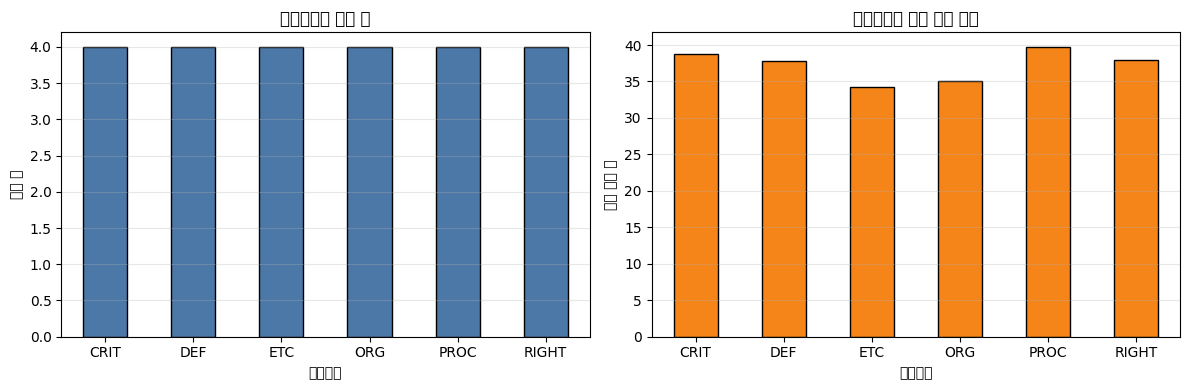

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

category_counts.plot(kind='bar', ax=axes[0], color='#4C78A8', edgecolor='black')
axes[0].set_title('카테고리별 샘플 수')
axes[0].set_xlabel('카테고리')
axes[0].set_ylabel('샘플 수')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', alpha=0.3)

mean_length = df.groupby('category')['length'].mean().sort_index()
mean_length.plot(kind='bar', ax=axes[1], color='#F58518', edgecolor='black')
axes[1].set_title('카테고리별 평균 문자 길이')
axes[1].set_xlabel('카테고리')
axes[1].set_ylabel('평균 문자 수')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()